**Pima Indian Diabetes EDA**

In [71]:
%matplotlib inline

Import Libraries

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn import metrics

In [73]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/pima-indians-diabetes-database


 Load Dataset

In [74]:
colnames = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
pima_df = pd.read_csv("/content/diabetes.csv")

In [75]:
pima_df.head(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [76]:
pima_df[~pima_df.map(np.isreal).all(1)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


**Preprocess Data**




Handle missing values


Convert categorical variables

Feature scaling (if needed)

In [77]:
pima_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [78]:
pima_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [79]:
pima_df.groupby("Outcome").count()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


In [80]:
print(pima_df.shape)
print(pima_df.columns)

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [81]:
pima_df_attr = pima_df.iloc[:,0:9]
print(pima_df_attr.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


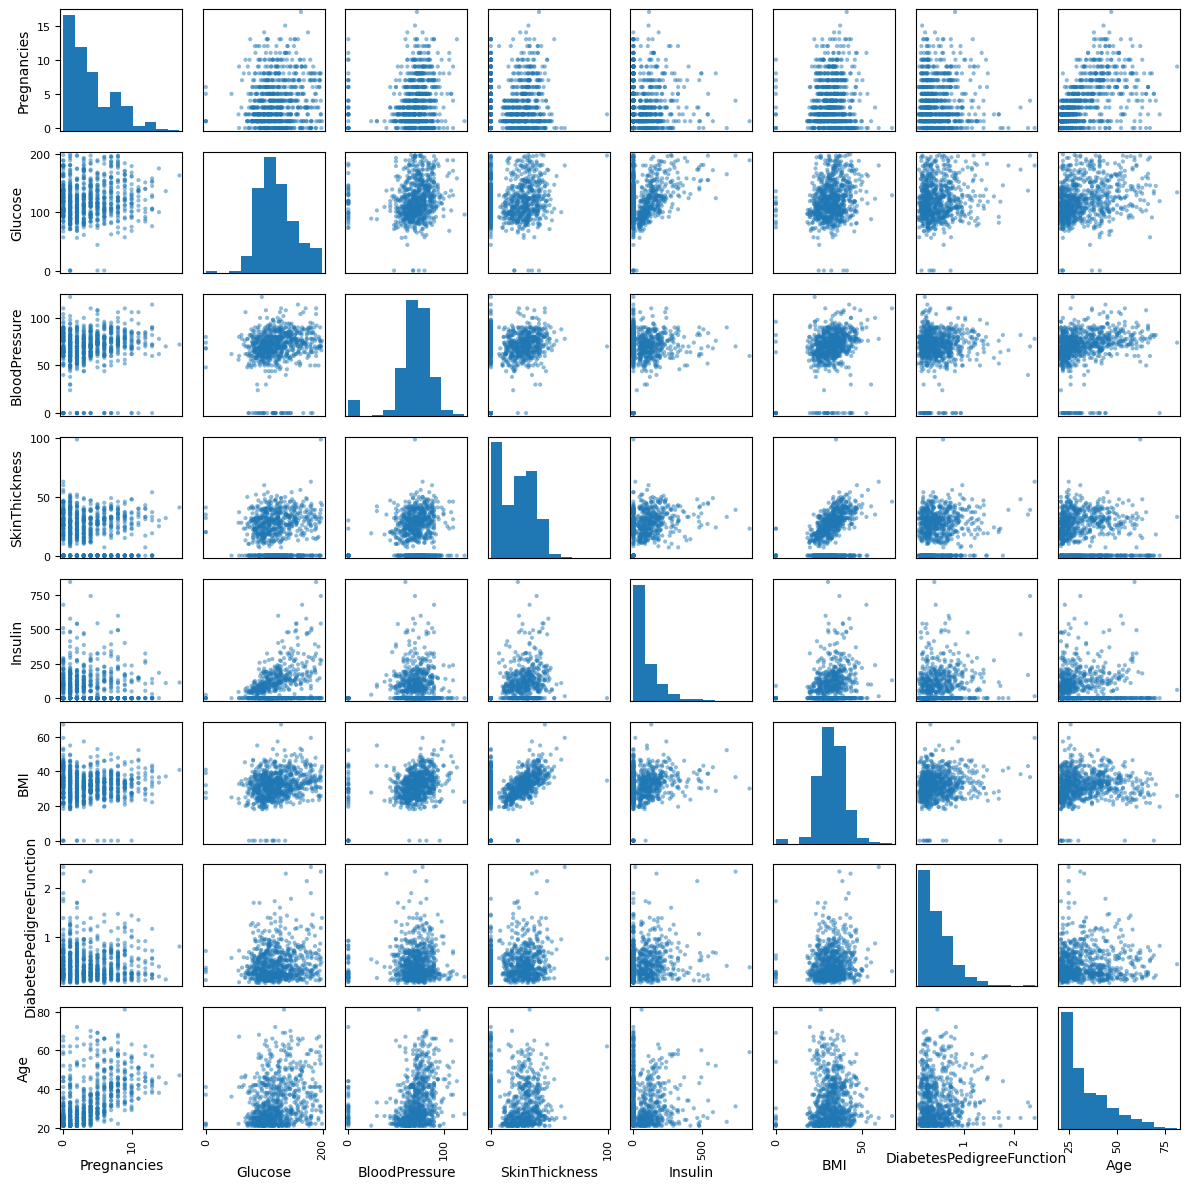

In [82]:
pima_df_attr = pima_df.iloc[:,0:-1]
axes = pd.plotting.scatter_matrix(pima_df_attr, figsize=(12,12))
plt.tight_layout()
plt.show()

In [83]:
array = pima_df.values
X = array[:,0:8]
Y = array[:,8]
test_size = 0.3
seed = 7
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [84]:
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

model = LogisticRegression() # Call the function with the correct name
model.fit(X_train, Y_train)
y_predict = model.predict(X_test)

coef_df = pd.DataFrame(model.coef_, columns=pima_df_attr.columns)
coef_df["Intercept"] = model.intercept_
print(coef_df)

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.131168  0.029769      -0.020253       0.001727 -0.001013  0.066506   

   DiabetesPedigreeFunction       Age  Intercept  
0                  1.996165  0.010106  -6.848698  


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
model_score = model.score(X_test, Y_test)
print(model_score)
print(metrics.confusion_matrix(Y_test, y_predict))

0.7489177489177489
[[127  20]
 [ 38  46]]


Analyzing the confusion matrix True Positives (TP): we correctly predicted that they do have diabetes 46

True Negatives (TN): we correctly predicted that they don't have diabetes 134

False Positives (FP): we incorrectly predicted that they do have diabetes (a "Type I error") 13 Falsely predict positive Type I error

False Negatives (FN): we incorrectly predicted that they don't have diabetes (a "Type II error") 38 Falsely predict negative Type II **error bold text









precision = TP/TP+FP -> high -> good

Recall = TP/TP+FN -> high ->

Precision

Correctness of positive predictions

Avoiding false positives (e.g., not flagging important emails as spam)

Recall

Completeness of capturing actual positives

Avoiding false negatives (e.g., not missing any spam)

Confusion Matrix

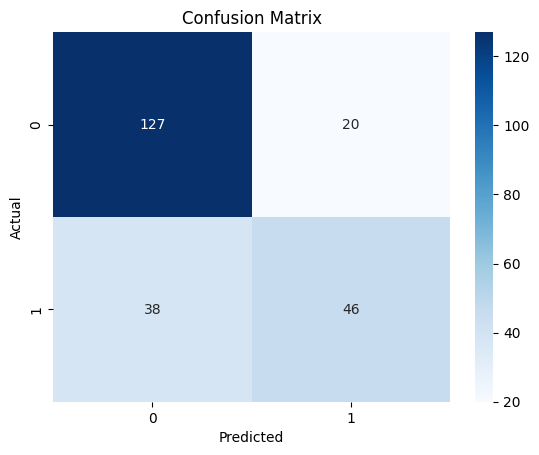

In [86]:
cm = metrics.confusion_matrix(Y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [87]:
import joblib
joblib.dump(model, 'logistic_model.pkl')

['logistic_model.pkl']

 Make Predictions

In [88]:
y_predict = model.predict(X_test)

In [89]:
model = LogisticRegression()
model.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [90]:
 X = pima_df.drop('Outcome', axis=1)  # Replace 'target_column' with 'Outcome'
Y = pima_df['Outcome']  # Replace 'target_column' with 'Outcome'

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, Y_train)
y_predict  = model.predict(X_test_scaled)


In [92]:
model = LogisticRegression(max_iter=1000)

In [93]:
scaler = StandardScaler()


Evaluate Model

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Split the dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    pima_df.drop('Outcome', axis=1),
    pima_df['Outcome'],
    test_size=0.2,
    random_state=42
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model with increased max_iter
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)

# Predict on scaled test data
y_predict = model.predict(X_test_scaled)

# Calculate metrics
precision = metrics.precision_score(Y_test, y_predict)
recall = metrics.recall_score(Y_test, y_predict)
accuracy = metrics.accuracy_score(Y_test, y_predict)
f1 = metrics.f1_score(Y_test, y_predict)

# Print results
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
print("F1 Score:", f1)


Precision: 0.6491228070175439
Recall: 0.6727272727272727
Accuracy: 0.7532467532467533
F1 Score: 0.6607142857142857
